<a href="https://colab.research.google.com/github/teemus28/Machine-Learning/blob/main/FE_feature_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
#df = pd.read_csv("/content/concrete_data.csv")

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
import numpy as np

In [ ]:
import seaborn as sbn

In [ ]:
iris = sbn.load_dataset("iris")

In [ ]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [ ]:
X=iris.iloc[:,0:4]
Y=iris.iloc[:,4]

In [ ]:
X.sample()

,sepal_length,sepal_width,petal_length,petal_width
7,5.0,3.4,1.5,0.2


In [ ]:
Y.sample()

66    versicolor
Name: species, dtype: object

Univariate selection

In [ ]:
best_feature =SelectKBest(score_func=chi2,k=2)

In [ ]:
#fit = best_feature.fit_transform(X,Y)

In [ ]:
fit = best_feature.fit(X,Y)

In [ ]:
#fit = pd.DataFrame(fit)

In [ ]:
fit.scores_

array([ 10.81782088,   3.7107283 , 116.31261309,  67.0483602 ])

In [ ]:
feature_fit=pd.DataFrame(fit.scores_)
feature_col=pd.DataFrame(X.columns)

In [ ]:
scores = pd.concat([feature_col,feature_fit],axis=1)
scores.columns=['columns','scores']

In [ ]:
scores

,columns,scores
0,sepal_length,10.817821
1,sepal_width,3.710728
2,petal_length,116.312613
3,petal_width,67.048360


In [ ]:
scores.nlargest(2,'scores')

,columns,scores
2,petal_length,116.312613
3,petal_width,67.048360


In [ ]:
#check accuracy

Feature importance

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
etc = ExtraTreesClassifier()
etc.fit(X,Y)

ExtraTreesClassifier()

In [ ]:
etc.feature_importances_

array([0.11163641, 0.06591368, 0.40786383, 0.41458608])

In [ ]:
selected = pd.Series(etc.feature_importances_,index=X.columns)
selected

sepal_length    0.111636
sepal_width     0.065914
petal_length    0.407864
petal_width     0.414586
dtype: float64

<Axes: >

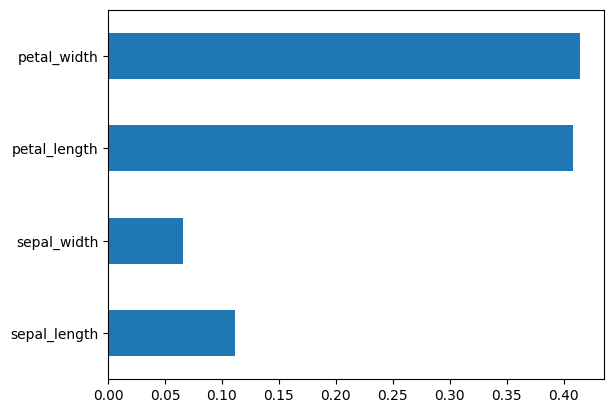

In [ ]:
import matplotlib.pyplot as plt
selected.plot(kind='barh')

correlation matrix using heat map

In [ ]:
import seaborn as sbn

In [ ]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
y_txn = oe.fit_transform(iris[['species']])

In [ ]:
iris['species'] = pd.DataFrame(y_txn)

In [ ]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [ ]:
relation = iris.corr()

In [ ]:
heatmap_data = relation.index
sbn.heatmap(iris['heatmap_data'].corr(), annot=True, cmap='viridis', cbar=True)

KeyError: 'heatmap_data'

In [ ]:
#sbn.heatmap(iris['heatmap_data'].corr(), annot=True, cmap='viridis', cbar=True)